In [5]:
#Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows. (Show the shape and column names as well.)

import pandas as pd

# Load the CSV file (adjust the path as needed)
df = pd.read_csv('BIKE DETAILS (EDA Assignment Resource).csv')

# Display first 10 rows
print(df.head(10))

# Show dataset shape and column names
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

                                   name  selling_price  year seller_type  \
0             Royal Enfield Classic 350         175000  2019  Individual   
1                             Honda Dio          45000  2017  Individual   
2   Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
3     Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
4                 Yamaha SZ [2013-2014]          20000  2011  Individual   
5                      Honda CB Twister          18000  2010  Individual   
6                  Honda CB Hornet 160R          78500  2018  Individual   
7  Royal Enfield Bullet 350 [2007-2011]         180000  2008  Individual   
8                Hero Honda CBZ extreme          30000  2010  Individual   
9                    Bajaj Discover 125          50000  2016  Individual   

       owner  km_driven  ex_showroom_price  
0  1st owner        350                NaN  
1  1st owner       5650                NaN  
2  1st owner      12000     

In [6]:
#Question 2: Check for missing values in all columns and describe your approach for handling them.

# Count missing values per column
missing_counts = df.isnull().sum()
print(missing_counts)

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


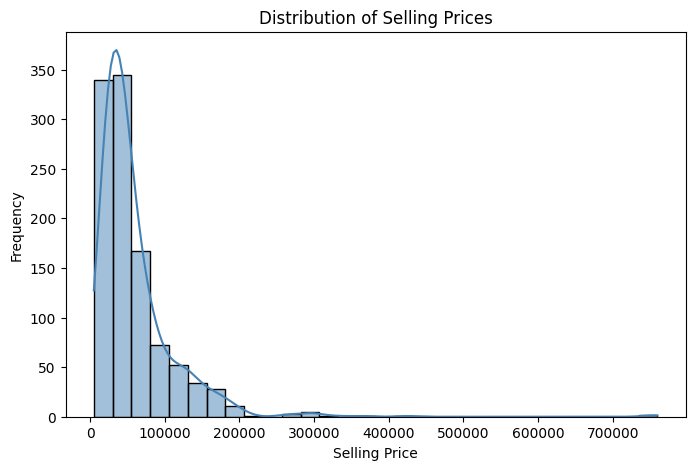

In [7]:
#Question 3: Plot the distribution of selling prices using a histogram and describe the overall trend.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['selling_price'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-1612054833.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price, x='seller_type', y='selling_price', palette='viridis')


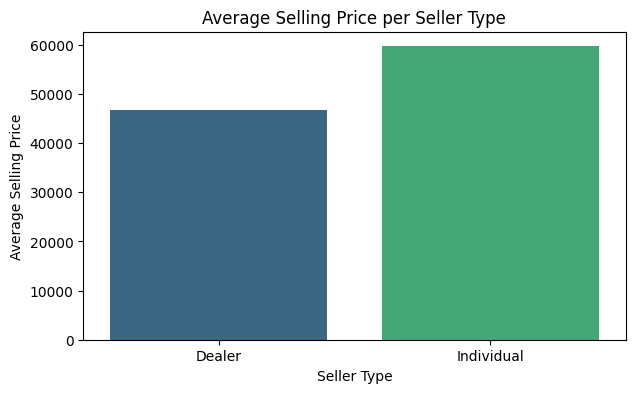

In [8]:
#Question 4: Create a bar plot to visualize the average selling price for each seller_type and write one observation.

# Calculate average price per seller type
avg_price = df.groupby('seller_type')['selling_price'].mean().reset_index()

# Bar plot
plt.figure(figsize=(7, 4))
sns.barplot(data=avg_price, x='seller_type', y='selling_price', palette='viridis')
plt.title('Average Selling Price per Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.show()

/tmp/ipython-input-552385247.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=km_avg, x='owner', y='km_driven', palette='magma')


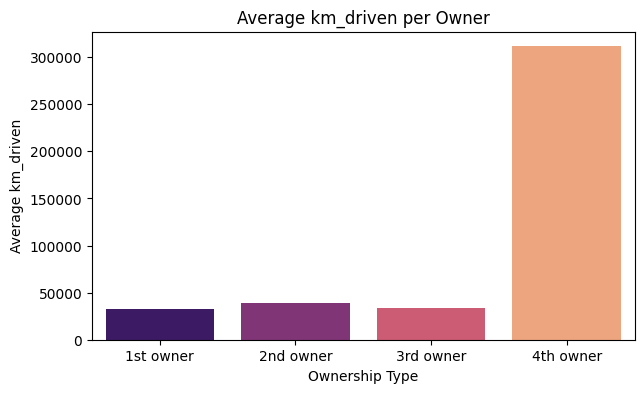

In [10]:
#Question 5: Compute the average km_driven for each ownership type (1st owner, 2nd owner, etc.), and present the result as a bar plot.

# Compute average km_driven per ownership category
km_avg = df.groupby('owner')['km_driven'].mean().reset_index()

# Bar plot
plt.figure(figsize=(7, 4))
sns.barplot(data=km_avg, x='owner', y='km_driven', palette='magma')
plt.title('Average km_driven per Owner')
plt.xlabel('Ownership Type')
plt.ylabel('Average km_driven')
plt.show()

In [11]:
#Question 6: Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.

# Step 1: Calculate quartiles and IQR
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Remove outliers
df_clean = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# Summary statistics before & after
summary_before = df['km_driven'].describe()
summary_after  = df_clean['km_driven'].describe()

print('Before cleaning:\n', summary_before)
print('\nAfter cleaning:\n', summary_after)

Before cleaning:
 count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

After cleaning:
 count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


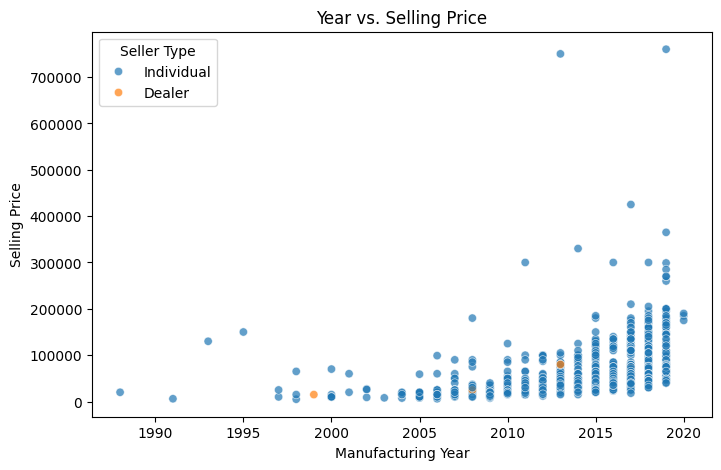

In [12]:
#Question 7: Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price.

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='year', y='selling_price', hue='seller_type', alpha=0.7)
plt.title('Year vs. Selling Price')
plt.xlabel('Manufacturing Year')
plt.ylabel('Selling Price')
plt.legend(title='Seller Type')
plt.show()

In [13]:
#Question 8: Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.

# One-hot encode seller_type
df_encoded = pd.get_dummies(df, columns=['seller_type'], drop_first=True)

# Show the first 5 rows of the transformed DataFrame
print(df_encoded.head(5))

                                  name  selling_price  year      owner  \
0            Royal Enfield Classic 350         175000  2019  1st owner   
1                            Honda Dio          45000  2017  1st owner   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  1st owner   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  1st owner   
4                Yamaha SZ [2013-2014]          20000  2011  2nd owner   

   km_driven  ex_showroom_price  seller_type_Individual  
0        350                NaN                    True  
1       5650                NaN                    True  
2      12000           148114.0                    True  
3      23000            89643.0                    True  
4      21000                NaN                    True  


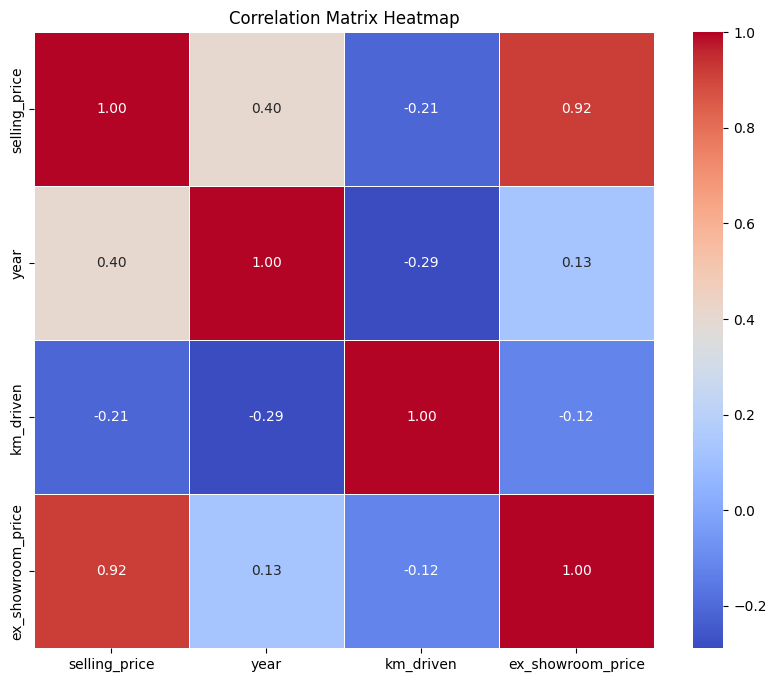

In [14]:
#Question 9: Generate a heatmap of the correlation matrix for all numeric columns. What correlations stand out the most?

import numpy as np
import seaborn as sns

# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Question 10: Summarize your findings in a brief report:

- What are the most important factors affecting a bike's selling price?
- Mention any data cleaning or feature engineering you performed.

Answer:-

Key factors influencing selling price:-

- Manufacturing year (age)

- km_driven (usage)

- seller_type (dealer vs. individual)

- Ownership history (e.g., 1st owner vs. 2nd owner)

Data cleaning steps:-

- Identified and removed outliers in km_driven using the IQR method.

- Handled missing values (imputation or removal) as appropriate.

Feature engineering:-

- Applied one-hot encoding to seller_type.

- Created any derived metrics (e.g., bike age = current year – year).